# 01 · Розвідувальний аналіз даних (EDA)

**Задача:** передбачити швидкість адопції тварини (`AdoptionSpeed`) на PetFinder.my
за текстовим описом та фотографіями. Метрика — *quadratic weighted kappa* (QWK).

**Мета цього ноутбука:** зрозуміти структуру даних, розподіл цільової змінної,
особливості текстів і зображень, щоб обґрунтовано спланувати моделювання.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import *
from src.utils import seed_everything, qwk, OptimizedRounder, write_submission
from src.data import load_data, build_image_index, add_photo_count, add_folds, text_meta_features

seed_everything(SEED)
pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")

## 1. Завантаження даних

In [2]:
train, test = load_data()
print("train:", train.shape, " test:", test.shape)
print("test має таргет:", TARGET_COL in test.columns)
train.head(3)

train: (6431, 3)  test: (1891, 2)
test має таргет: False


,PetID,Description,AdoptionSpeed
0,d3b4f29f8,"Mayleen and Flo are two lovely adorable sisters. They are very friendly and affectionate, but wary of strangers and make good watchdogs. Mayleen has golden hues on her face, making her a husky loo...",2
1,e9dc82251,"A total of 5 beautiful Tabbys available for adoption. Orange Tabbys and Grey Tabbys. They are all approx 6 weeks old and without any injuries, healthy and playful. Free spaying and neutering can b...",2
2,8111f6d4a,Two-and-a-half month old girl. Very manja and cute.,2


## 2. Цільова змінна

Перевіряємо діапазон класів (0–4 чи 1–4) та дисбаланс.

,count,share
AdoptionSpeed,,
1,1197,0.186
2,1773,0.276
3,1328,0.206
4,2133,0.332


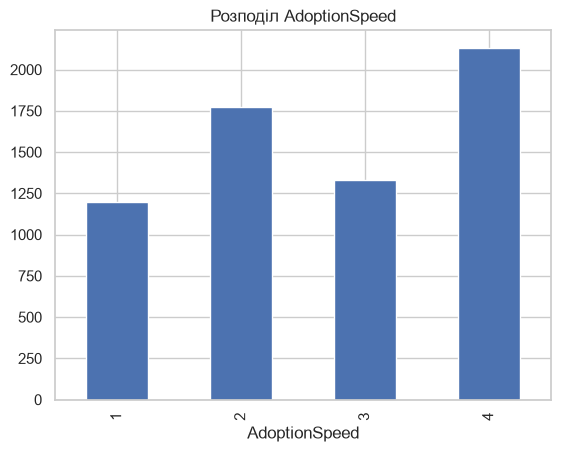

In [3]:
vc = train[TARGET_COL].value_counts().sort_index()
display(vc.to_frame("count").assign(share=lambda d: (d["count"] / len(train)).round(3)))
vc.plot.bar(title="Розподіл AdoptionSpeed");

## 3. Текстові описи

Довжина, порожні описи, мова, приклади по класах.

,count,mean,std,min,25%,50%,75%,max
desc_len,6431.0,364.184730,410.726359,0.0,124.000000,250.000000,455.0000,5798.0
desc_words,6431.0,67.442233,76.088326,0.0,22.000000,46.000000,85.0000,1153.0
desc_upper_ratio,6431.0,0.038668,0.067236,0.0,0.017475,0.025445,0.0388,1.0
desc_excl,6431.0,0.369149,1.131319,0.0,0.000000,0.000000,0.0000,21.0
desc_digits,6431.0,1.461204,2.987742,0.0,0.000000,0.000000,2.0000,38.0
desc_is_empty,6431.0,0.000777,0.027875,0.0,0.000000,0.000000,0.0000,1.0
desc_non_ascii,6431.0,0.005170,0.055525,0.0,0.000000,0.000000,0.0000,1.0


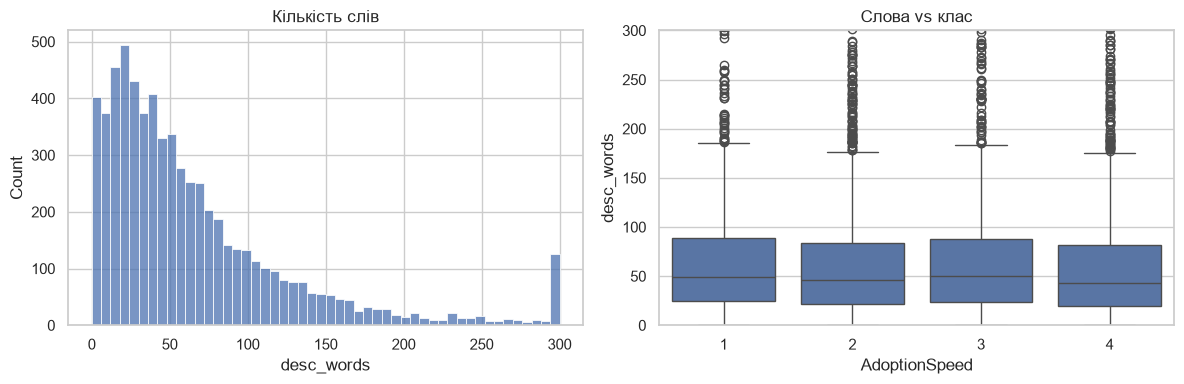

In [4]:
meta = text_meta_features(train[TEXT_COL])
train_m = pd.concat([train, meta], axis=1)
display(meta.describe().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_m["desc_words"].clip(upper=300), bins=50, ax=axes[0]).set_title("Кількість слів")
sns.boxplot(data=train_m, x=TARGET_COL, y="desc_words", ax=axes[1]).set(ylim=(0, 300), title="Слова vs клас")
plt.tight_layout();

In [5]:
# Empty descriptions and non-ASCII share by target class
train_m.groupby(TARGET_COL)[["desc_is_empty", "desc_non_ascii", "desc_words"]].mean().round(3)

,desc_is_empty,desc_non_ascii,desc_words
AdoptionSpeed,,,
1,0.001,0.002,68.475
2,0.001,0.002,68.670
3,0.001,0.003,71.697
4,0.000,0.011,63.193


In [6]:
# A few random examples per class to get a feel for the texts
for c in sorted(train[TARGET_COL].unique()):
    print(f"=== AdoptionSpeed = {c} ===")
    for t in train.loc[train[TARGET_COL] == c, TEXT_COL].sample(2, random_state=SEED):
        print(" -", t[:250].replace("\n", " "))
    print()

=== AdoptionSpeed = 1 ===
 - Found with choke chain in damansara jaya
 - M looking for a loving parents for them. Adoption fee is negotiable.

=== AdoptionSpeed = 2 ===
 - The 3 kittens was abandoned and found in a nearby garden. For more information please call my mobile number.
 - She is a dog that I rescued nearby my house. I am finding her a home now n hope u can be her next master.She is a teen husky, so u can expect she is very curious about every things n get ur house some kind of trouble. If ur hav other dogs in house, u

=== AdoptionSpeed = 3 ===
 - Lovely puppy looking for a forever home. If u are interested to afopt pls contact Rachel
 - This boy two week ago is getting serious injury on his neck,his neck had one big hole and the hole are fully filled flies worms,when i feeding other dogs at outside i hear some noise at the bridge then i go to the bridge and bring them out after i go

=== AdoptionSpeed = 4 ===
 - toilet trained
 - They are very cute. I really appreciate if s

## 4. Зображення

Скільки фото на тварину, скільки тварин без фото, розміри зображень.

In [7]:
img_index = build_image_index()
print("images:", len(img_index), " pets with photos:", img_index[ID_COL].nunique())
img_index.head()

images: 37920  pets with photos: 8330


,PetID,path,img_idx,split
0,0008c5398,C:\Users\pbori\Documents\Courses\Neoversity\DeepL\neoversity-dl-cv-final\data\raw\images\test\0008c5398-1.jpg,1,test
1,0008c5398,C:\Users\pbori\Documents\Courses\Neoversity\DeepL\neoversity-dl-cv-final\data\raw\images\test\0008c5398-2.jpg,2,test
2,0008c5398,C:\Users\pbori\Documents\Courses\Neoversity\DeepL\neoversity-dl-cv-final\data\raw\images\test\0008c5398-3.jpg,3,test
3,0008c5398,C:\Users\pbori\Documents\Courses\Neoversity\DeepL\neoversity-dl-cv-final\data\raw\images\test\0008c5398-4.jpg,4,test
4,0008c5398,C:\Users\pbori\Documents\Courses\Neoversity\DeepL\neoversity-dl-cv-final\data\raw\images\test\0008c5398-5.jpg,5,test


train без фото: 0.0
test  без фото: 0.0


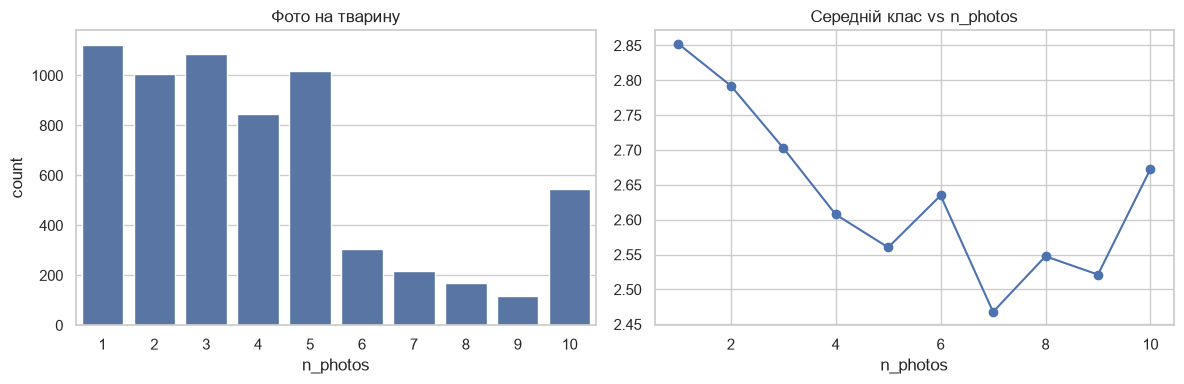

In [8]:
train_m = add_photo_count(train_m, img_index)
test_p = add_photo_count(test, img_index)

print("train без фото:", (train_m["n_photos"] == 0).mean().round(3))
print("test  без фото:", (test_p["n_photos"] == 0).mean().round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=train_m["n_photos"].clip(upper=10), ax=axes[0]).set_title("Фото на тварину")
train_m.groupby("n_photos")[TARGET_COL].mean().loc[:10].plot(ax=axes[1], marker="o", title="Середній клас vs n_photos")
plt.tight_layout();

In [9]:
# Image sizes on a random sample
from PIL import Image

sizes = [Image.open(p).size for p in img_index["path"].sample(200, random_state=SEED)]
pd.DataFrame(sizes, columns=["w", "h"]).describe().T

,count,mean,std,min,25%,50%,75%,max
w,200.0,406.265,128.068429,200.0,300.0,400.0,400.0,640.0
h,200.0,411.970,92.316471,207.0,300.0,400.0,480.0,640.0


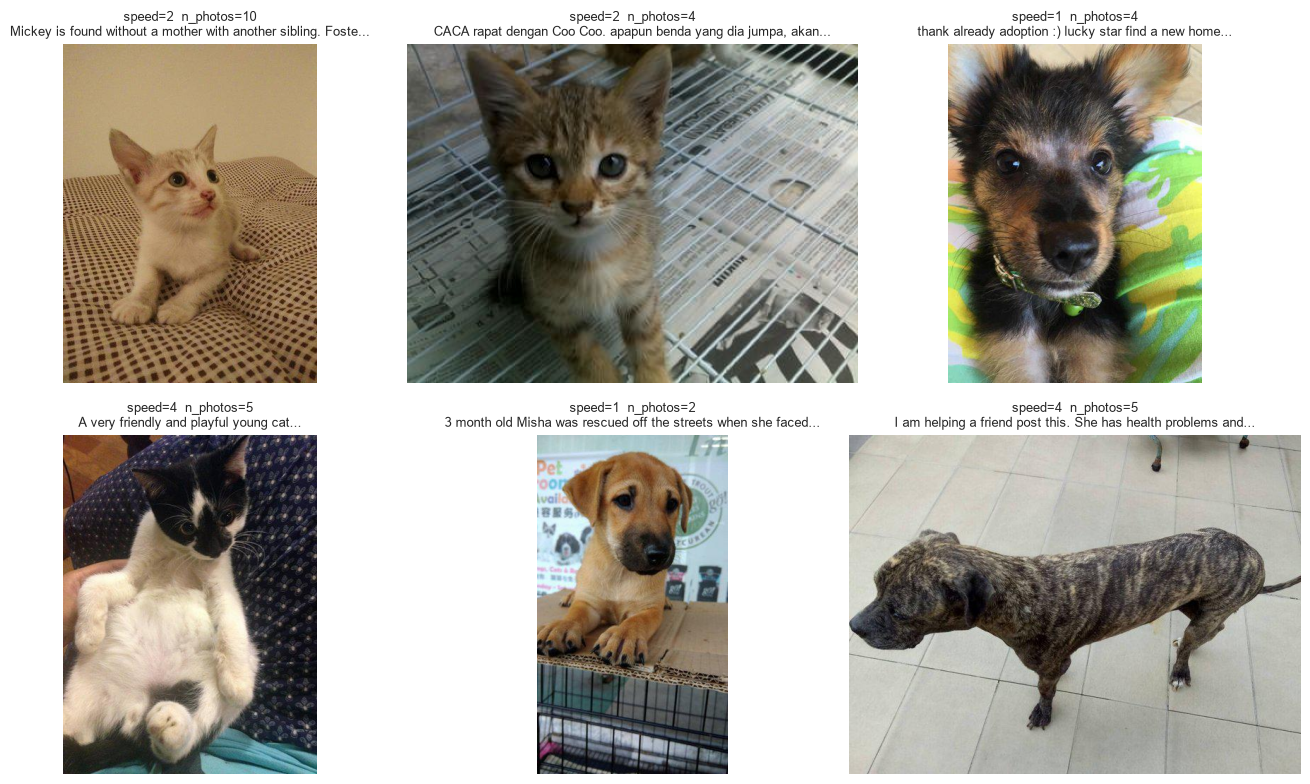

In [10]:
# Show several photos with their descriptions
sample = train_m[train_m["n_photos"] > 0].sample(6, random_state=SEED)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (_, row) in zip(axes.ravel(), sample.iterrows()):
    path = img_index.loc[img_index[ID_COL] == row[ID_COL], "path"].iloc[0]
    ax.imshow(Image.open(path)); ax.axis("off")
    ax.set_title(f"speed={row[TARGET_COL]}  n_photos={row['n_photos']}\n{row[TEXT_COL][:60]}...", fontsize=9)
plt.tight_layout();

## 5. Збереження фолдів та мета-ознак

Фолди фіксуємо один раз, щоб усі наступні ноутбуки використовували однакову валідацію.

In [11]:
train_f = add_folds(train_m)
train_f.to_parquet(PROCESSED_DIR / "train_meta.parquet", index=False)
test_p.to_parquet(PROCESSED_DIR / "test_meta.parquet", index=False)
img_index.to_parquet(PROCESSED_DIR / "image_index.parquet", index=False)
train_f["fold"].value_counts().sort_index()

fold
0    1287
1    1286
2    1286
3    1286
4    1286
Name: count, dtype: int64

## Висновки

_(заповнити після аналізу)_

- Розподіл таргету: …
- Тексти: …
- Зображення: …
- Що це означає для моделювання: …